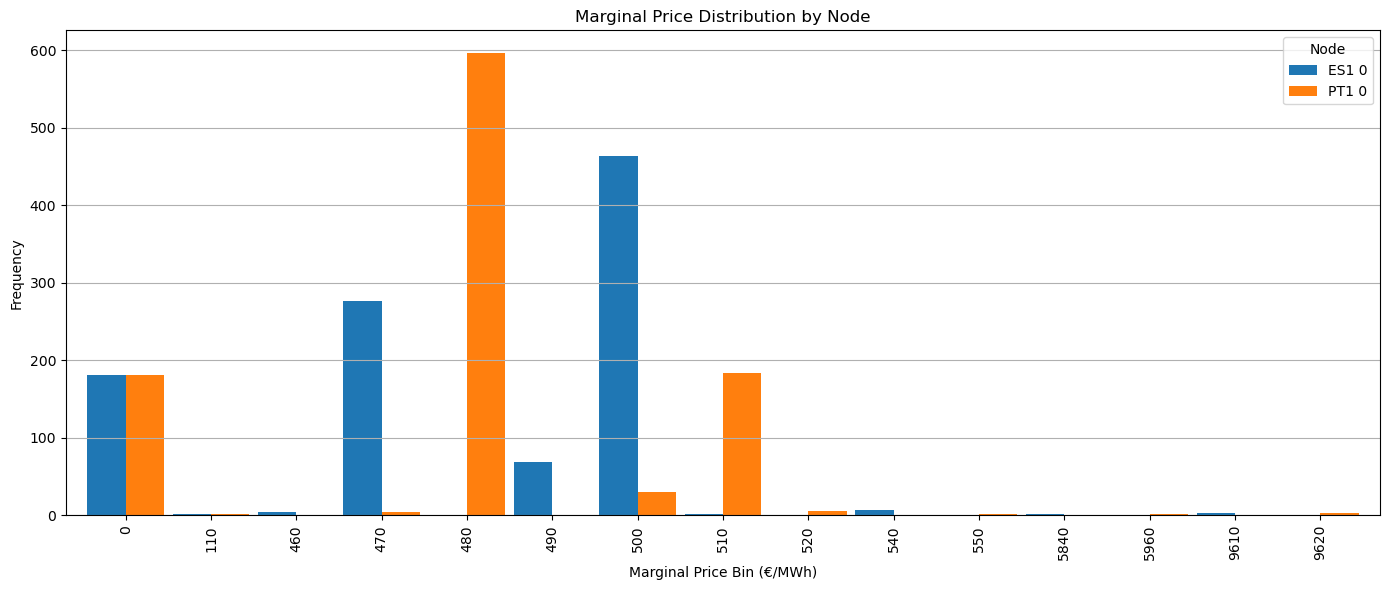

In [ ]:
def plot_price_frequency_per_node(
    dual_variables,
    nodes_to_plot=None,
    bin_width=10,
    title="Marginal Price Distribution by Node",
):
    """
    Plot a frequency diagram of marginal prices for each node.

    Parameters:
    - dual_variables: dict containing 'power_balance_duals' DataFrame
    - nodes_to_plot: list of node names (optional). If None, uses the first 3.
    - bin_width: price bin width for histogram (e.g., 10 €/MWh)
    - title: plot title
    """
    df = dual_variables["power_balance_duals"].copy().reset_index()

    if nodes_to_plot is None:
        nodes_to_plot = df["node"].unique()[:3]

    # Round dual values to bin centers
    df["price_bin"] = (df["dual_value"] // bin_width * bin_width).astype(int)

    # Filter to selected nodes
    df = df[df["node"].isin(nodes_to_plot)]

    # Count occurrences per (node, price_bin)
    freq_df = df.groupby(["node", "price_bin"]).size().reset_index(name="count")

    # Pivot for plotting
    pivot_df = freq_df.pivot(index="price_bin", columns="node", values="count").fillna(
        0
    )

    # Sort bins
    pivot_df = pivot_df.sort_index()

    # Plot
    pivot_df.plot(kind="bar", figsize=(14, 6), width=0.9)
    plt.xlabel("Marginal Price Bin (€/MWh)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend(title="Node")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


# Call the function
plot_price_frequency_per_node(
    dual_variables, nodes_to_plot=["ES1 0", "PT1 0"], bin_width=10
)